# Initial Verification - My Local Machine

In [ ]:
# Brief test to see if GPU is set properly to work here
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

True
NVIDIA GeForce RTX 4060 Laptop GPU


# CIFAR-10 Data Preprocessing

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Define Augmentation and Normalization
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 2. Download Datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# 3. Create Data Loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Data loaded successfully! Training batches: {len(train_loader)}, Testing batches: {len(test_loader)}")

c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torchvision\io\image.py:14: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Data loaded successfully! Training batches: 782, Testing batches: 157


# Problem 1 - Refitting AlexNet to accept Cifar-10 data

## Step 1: Data Preprocessing & Loading Setup
* RandomCrop(32, padding=4): Pads the edges by 4 pixels and takes a random 32x32 slice. This stops the model from just memorizing exact pixel layouts.

* RandomHorizontalFlip: 50% chance to flip the image, basically doubling our dataset size so it learns general shapes.

* ToTensor: Converts standard image pixels (0-255) into PyTorch tensors (0.0-1.0).

* Normalize: Centers the data around zero to speed up training using (Pixel - Mean) / StdDev. The specific numbers used are the exact calculated global RGB means and standard deviations for the entire CIFAR-10 dataset.

* DataLoader: Groups data into batches of 64 so it doesn't crash the GPU. shuffle=True makes sure each batch has a random mix of classes (like frogs, cars, planes) so the model doesn't get stuck learning just one class at a time.

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Setup transforms based on CIFAR-10 global means/std to keep training stable
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Prevent pixel-location memorization
    transforms.RandomHorizontalFlip(),    # Basic augmentation
    transforms.ToTensor(),                # Convert to float 0.0-1.0
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Test data only gets normalized, no random flipping/cropping
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Download and apply transforms
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Group into batches of 64 to fit GPU VRAM. Shuffle training data to prevent order-bias.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Loaded! Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

0.0%

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Loaded! Train batches: 782, Test batches: 157


## Step 2: Patching the Data Loaders (Adding Validation & Seed)

In [5]:
import torch
from torch.utils.data import random_split, DataLoader

# Set random seed for reusability
SEED = 7
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Split the 50k train dataset into 40k train / 10k val
generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(train_dataset, [40000, 10000], generator=generator)

# Recreate the loaders with the new split
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2) # Remains the same

print(f"Data Split -> Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}")

Data Split -> Train: 40000, Val: 10000, Test: 10000


# Part A

## Step 3: Our Baseline in AlexNet

In [6]:
import torch.nn as nn

class ModifiedAlexNet(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(ModifiedAlexNet, self).__init__()
        
        self.features = nn.Sequential(
            # Conv 1: Scaled down from 11x11 to 3x3 to preserve spatial dimensions of 32x32 inputs
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Pool 1: 2x2 window with stride 2 reduces spatial size from 32x32 to 16x16
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv 2: Scaled down from 5x5 to 3x3
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # Pool 2: Reduces spatial size from 16x16 to 8x8
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv 3, 4, 5: Maintained 3 stacked convolutional layers but reduced channel widths
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # Pool 3: Reduces spatial size from 8x8 to 4x4
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate), 
            # Linear 1: Adjusted input to match flattened 256 channels of 4x4 grids.
            # Hidden layers reduced from 4096 to 1024 to prevent overfitting on CIFAR-10.
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 10), # 10 output classes for CIFAR-10
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # Flattens the tensor for the fully connected layers
        x = self.classifier(x)
        return x

## Step 4: Getting that Parameter Count

In [ ]:
from torchinfo import summary

# Create the model and process it in the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ModifiedAlexNet(dropout_rate=0.0).to(device)

# Summarize assuming a batch size of 64, 3 color channels, 32x32 image
summary(model, input_size=(64, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedAlexNet                          [64, 10]                  --
├─Sequential: 1-1                        [64, 256, 4, 4]           --
│    └─Conv2d: 2-1                       [64, 64, 32, 32]          1,792
│    └─ReLU: 2-2                         [64, 64, 32, 32]          --
│    └─MaxPool2d: 2-3                    [64, 64, 16, 16]          --
│    └─Conv2d: 2-4                       [64, 192, 16, 16]         110,784
│    └─ReLU: 2-5                         [64, 192, 16, 16]         --
│    └─MaxPool2d: 2-6                    [64, 192, 8, 8]           --
│    └─Conv2d: 2-7                       [64, 384, 8, 8]           663,936
│    └─ReLU: 2-8                         [64, 384, 8, 8]           --
│    └─Conv2d: 2-9                       [64, 256, 8, 8]           884,992
│    └─ReLU: 2-10                        [64, 256, 8, 8]           --
│    └─Conv2d: 2-11                      [64, 256, 8, 8]           

## Step 5: Training Loop & Metric Tracking Setup

In [9]:
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Define Loss, Optimizer, and Learning Rate Scheduler
criterion = nn.CrossEntropyLoss()
# Using standard SGD with momentum as used in the original AlexNet paper
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# Learning rate scheduler to reduce the LR by half every 10 epochs to stabilize convergence
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 2. Initialize tracking lists for plotting later
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

epochs = 30

print(f"Starting training on device: {device}")

# 3. Core Training Loop
for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()      # Clear previous gradients
        outputs = model(inputs)     # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()            # Backward pass (gradients)
        optimizer.step()           # Update weights
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # 4. Validation Phase (Evaluated at the end of every epoch)
    model.eval() # Set model to evaluation mode (turns off batchnorm/dropout behaviors)
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Disable gradient calculation for efficiency
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Step the learning rate scheduler
    scheduler.step()
    
    # Save metrics to history lists
    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)
    
    # Print progress updates
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.4f} | "
          f"Train Loss: {epoch_train_loss:.4f} Old Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.2f}%")

print("Training complete!")

Starting training on device: cuda
Epoch [1/30] | LR: 0.0100 | Train Loss: 2.0064 Old Train Acc: 24.28% | Val Loss: 1.7045 Val Acc: 35.40%
Epoch [2/30] | LR: 0.0100 | Train Loss: 1.5719 Old Train Acc: 41.75% | Val Loss: 1.3942 Val Acc: 48.63%
Epoch [3/30] | LR: 0.0100 | Train Loss: 1.3375 Old Train Acc: 50.87% | Val Loss: 1.3496 Val Acc: 51.35%
Epoch [4/30] | LR: 0.0100 | Train Loss: 1.1533 Old Train Acc: 58.37% | Val Loss: 1.0875 Val Acc: 60.77%
Epoch [5/30] | LR: 0.0100 | Train Loss: 0.9887 Old Train Acc: 64.62% | Val Loss: 0.9424 Val Acc: 66.65%
Epoch [6/30] | LR: 0.0100 | Train Loss: 0.8742 Old Train Acc: 69.30% | Val Loss: 0.8543 Val Acc: 69.59%
Epoch [7/30] | LR: 0.0100 | Train Loss: 0.7894 Old Train Acc: 72.11% | Val Loss: 0.8244 Val Acc: 70.86%
Epoch [8/30] | LR: 0.0100 | Train Loss: 0.7246 Old Train Acc: 74.60% | Val Loss: 0.7350 Val Acc: 74.62%
Epoch [9/30] | LR: 0.0100 | Train Loss: 0.6676 Old Train Acc: 76.83% | Val Loss: 0.7011 Val Acc: 76.06%
Epoch [10/30] | LR: 0.0050 | T

## Step 6: Plotting the Training & Validation Curves

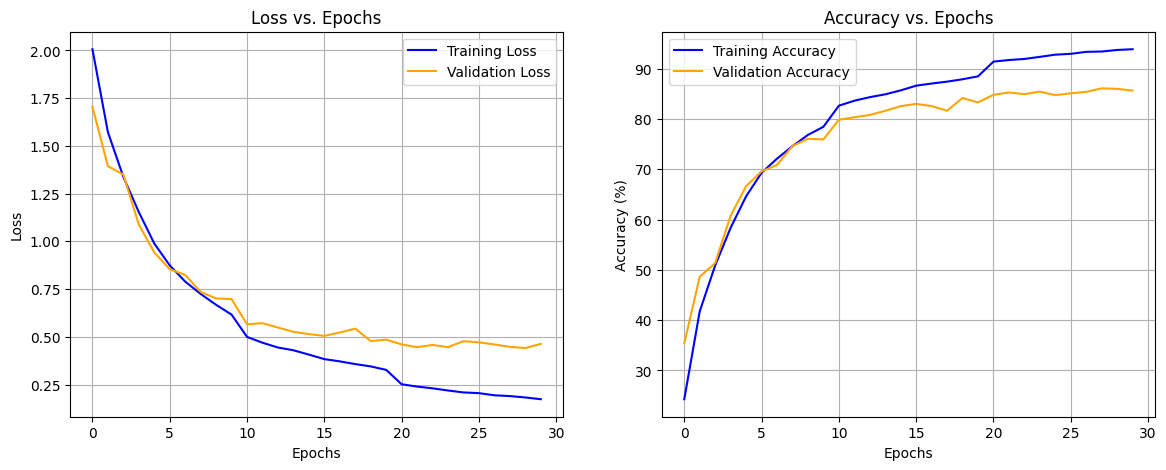

In [10]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(train_loss_history, label='Training Loss', color='blue')
ax1.plot(val_loss_history, label='Validation Loss', color='orange')
ax1.set_title('Loss vs. Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Accuracy Curve
ax2.plot(train_acc_history, label='Training Accuracy', color='blue')
ax2.plot(val_acc_history, label='Validation Accuracy', color='orange')
ax2.set_title('Accuracy vs. Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.show()

## Step 7: Final Test Accuracy & Confusion Matrix

Evaluating on the Test Set...
Final Test Accuracy: 86.40%


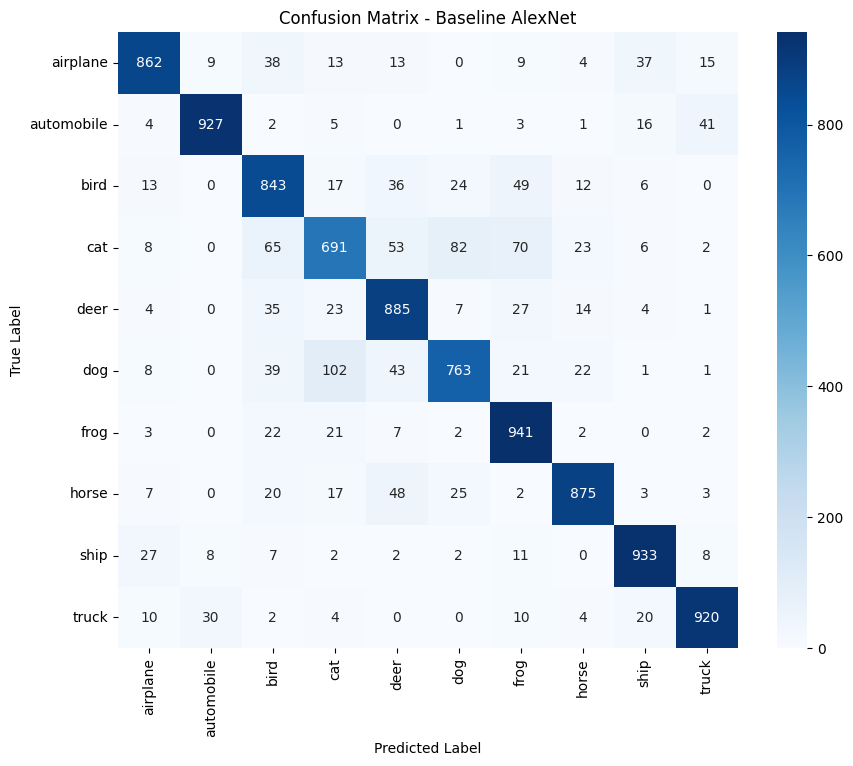

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []
correct_test = 0
total_test = 0

print("Evaluating on the Test Set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        
        # Save predictions and true labels for the confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_test_acc = (correct_test / total_test) * 100
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

# Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline AlexNet')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Part B

## Step 8: Learned filters

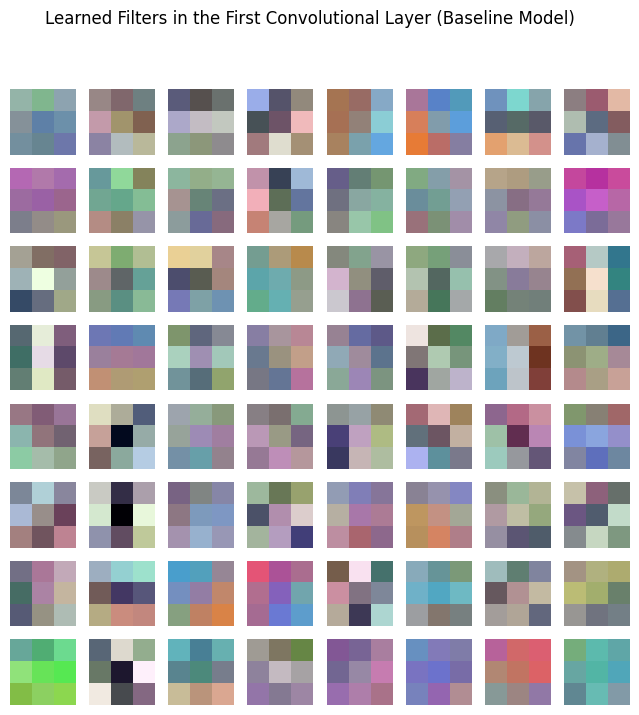

In [ ]:
import torch
import matplotlib.pyplot as plt

# Ensure we are pointing directly to your trained Part A baseline model
# Extract the weights of the very first convolutional layer
conv1_weights = model.features[0].weight.data.cpu()

# Normalize the weights to the 0-1 range so matplotlib can render them as colors
min_w, max_w = conv1_weights.min(), conv1_weights.max()
conv1_weights = (conv1_weights - min_w) / (max_w - min_w)

# Let's create an 8x8 grid to display all 64 filters
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    if i < conv1_weights.shape[0]:
        # Permute from (Channels, Height, Width) to (Height, Width, Channels) for plotting
        filter_img = conv1_weights[i].permute(1, 2, 0).numpy()
        ax.imshow(filter_img)
    ax.axis('off') # We can hide axes for a cleaner look

plt.suptitle('Learned Filters in the First Convolutional Layer (Baseline Model)')
plt.show()

## Step 9: Making Changes to Dropout (0.3)

In [17]:
import torch.optim as optim
import torch.nn as nn

# 1. Re-instantiate the model blueprint with 0.3 dropout
model_dropout_30 = ModifiedAlexNet(dropout_rate=0.3).to(device)

# 2. Reset the loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_dropout_30.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 3. Create fresh history tracking lists
train_loss_30, train_acc_30 = [], []
val_loss_30, val_acc_30 = [], []

epochs = 30
print(f"Starting Dropout p=0.3 training...")

# 4. Fully expanded training loop mapped to the 0.3 variables
for epoch in range(epochs):
    model_dropout_30.train() # Active dropout during training
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_dropout_30(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # Validation Phase
    model_dropout_30.eval() # Deactivates dropout for clean validation tracking
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_dropout_30(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    scheduler.step()
    
    # Save to 0.3 history lists
    train_loss_30.append(epoch_train_loss)
    train_acc_30.append(epoch_train_acc)
    val_loss_30.append(epoch_val_loss)
    val_acc_30.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("Dropout p=0.3 training complete!")

Starting Dropout p=0.3 training...
Epoch [1/30] | Train Loss: 2.0497 | Val Acc: 31.79%
Epoch [2/30] | Train Loss: 1.5931 | Val Acc: 46.20%
Epoch [3/30] | Train Loss: 1.3491 | Val Acc: 56.40%
Epoch [4/30] | Train Loss: 1.1489 | Val Acc: 61.04%
Epoch [5/30] | Train Loss: 0.9982 | Val Acc: 67.53%
Epoch [6/30] | Train Loss: 0.8896 | Val Acc: 70.58%
Epoch [7/30] | Train Loss: 0.7990 | Val Acc: 72.84%
Epoch [8/30] | Train Loss: 0.7347 | Val Acc: 73.89%
Epoch [9/30] | Train Loss: 0.6874 | Val Acc: 77.01%
Epoch [10/30] | Train Loss: 0.6320 | Val Acc: 77.56%
Epoch [11/30] | Train Loss: 0.5127 | Val Acc: 80.95%
Epoch [12/30] | Train Loss: 0.4936 | Val Acc: 80.82%
Epoch [13/30] | Train Loss: 0.4580 | Val Acc: 81.49%
Epoch [14/30] | Train Loss: 0.4381 | Val Acc: 82.59%
Epoch [15/30] | Train Loss: 0.4154 | Val Acc: 82.08%
Epoch [16/30] | Train Loss: 0.4054 | Val Acc: 82.64%
Epoch [17/30] | Train Loss: 0.3820 | Val Acc: 82.35%
Epoch [18/30] | Train Loss: 0.3752 | Val Acc: 84.02%
Epoch [19/30] | Trai

## Step 10: Changing Dropout to 0.5

In [18]:
# 1. Re-instantiate the model blueprint with 0.5 dropout
model_dropout_50 = ModifiedAlexNet(dropout_rate=0.5).to(device)

# 2. Reset the loss, optimizer, and scheduler
optimizer = optim.SGD(model_dropout_50.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 3. Create fresh history tracking lists
train_loss_50, train_acc_50 = [], []
val_loss_50, val_acc_50 = [], []

print(f"Starting Dropout p=0.5 training...")

# 4. Fully expanded training loop mapped to the 0.5 variables
for epoch in range(epochs):
    model_dropout_50.train() # Active dropout during training
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_dropout_50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # Validation Phase
    model_dropout_50.eval() # Deactivates dropout for clean validation tracking
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_dropout_50(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    scheduler.step()
    
    # Save to 0.5 history lists
    train_loss_50.append(epoch_train_loss)
    train_acc_50.append(epoch_train_acc)
    val_loss_50.append(epoch_val_loss)
    val_acc_50.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("Dropout p=0.5 training complete!")

Starting Dropout p=0.5 training...
Epoch [1/30] | Train Loss: 2.1163 | Val Acc: 28.33%
Epoch [2/30] | Train Loss: 1.6858 | Val Acc: 41.66%
Epoch [3/30] | Train Loss: 1.4223 | Val Acc: 55.42%
Epoch [4/30] | Train Loss: 1.2076 | Val Acc: 58.67%
Epoch [5/30] | Train Loss: 1.0463 | Val Acc: 66.72%
Epoch [6/30] | Train Loss: 0.9415 | Val Acc: 67.19%
Epoch [7/30] | Train Loss: 0.8573 | Val Acc: 69.95%
Epoch [8/30] | Train Loss: 0.7746 | Val Acc: 70.74%
Epoch [9/30] | Train Loss: 0.7241 | Val Acc: 75.81%
Epoch [10/30] | Train Loss: 0.6699 | Val Acc: 76.19%
Epoch [11/30] | Train Loss: 0.5519 | Val Acc: 80.63%
Epoch [12/30] | Train Loss: 0.5105 | Val Acc: 80.52%
Epoch [13/30] | Train Loss: 0.4838 | Val Acc: 81.65%
Epoch [14/30] | Train Loss: 0.4712 | Val Acc: 81.97%
Epoch [15/30] | Train Loss: 0.4503 | Val Acc: 81.98%
Epoch [16/30] | Train Loss: 0.4265 | Val Acc: 82.97%
Epoch [17/30] | Train Loss: 0.4067 | Val Acc: 82.64%
Epoch [18/30] | Train Loss: 0.3930 | Val Acc: 83.29%
Epoch [19/30] | Trai

## Step 11: Comparison

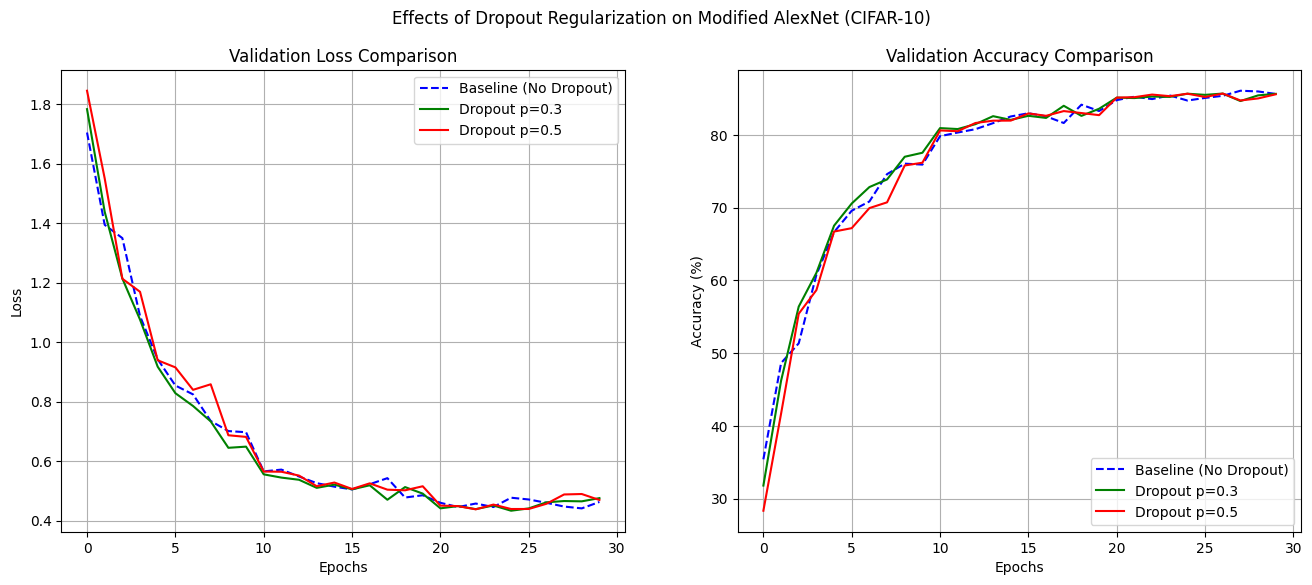

In [19]:
import matplotlib.pyplot as plt

# Create a figure for the grand comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Validation Loss Comparison ---
ax1.plot(val_loss_history, label='Baseline (No Dropout)', color='blue', linestyle='--')
ax1.plot(val_loss_30, label='Dropout p=0.3', color='green')
ax1.plot(val_loss_50, label='Dropout p=0.5', color='red')
ax1.set_title('Validation Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Validation Accuracy Comparison ---
ax2.plot(val_acc_history, label='Baseline (No Dropout)', color='blue', linestyle='--')
ax2.plot(val_acc_30, label='Dropout p=0.3', color='green')
ax2.plot(val_acc_50, label='Dropout p=0.5', color='red')
ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Effects of Dropout Regularization on Modified AlexNet (CIFAR-10)')
plt.show()

## Step 12: The Bonus Batch Normalization Model & Loop

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define the BatchNorm Variant Architecture
class AlexNetBatchNorm(nn.Module):
    def __init__(self):
        super(AlexNetBatchNorm, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384), # Added
            nn.ReLU(inplace=True),
            
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), # Added
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024),
            nn.BatchNorm1d(1024), # Added
            nn.ReLU(inplace=True),
            nn.Linear(1024, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 2. Instantiate and setup training environment
model_bn = AlexNetBatchNorm().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_bn.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_loss_bn, train_acc_bn = [], []
val_loss_bn, val_acc_bn = [], []

# 3. We Train for 30 epochs
print("Starting Batch Normalization (Bonus) training...")
for epoch in range(30):
    model_bn.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_bn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Validation
    model_bn.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_bn(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    scheduler.step()
    train_loss_bn.append(running_loss / len(train_loader.dataset))
    train_acc_bn.append((correct_train / total_train) * 100)
    val_loss_bn.append(running_val_loss / len(val_loader.dataset))
    val_acc_bn.append((correct_val / total_val) * 100)
    print(f"Epoch [{epoch+1}/30] | Val Acc: {val_acc_bn[-1]:.2f}%")

Starting Batch Normalization (Bonus) training...
Epoch [1/30] | Val Acc: 61.31%
Epoch [2/30] | Val Acc: 64.78%
Epoch [3/30] | Val Acc: 70.35%
Epoch [4/30] | Val Acc: 74.29%
Epoch [5/30] | Val Acc: 75.69%
Epoch [6/30] | Val Acc: 77.41%
Epoch [7/30] | Val Acc: 77.83%
Epoch [8/30] | Val Acc: 80.88%
Epoch [9/30] | Val Acc: 78.63%
Epoch [10/30] | Val Acc: 82.39%
Epoch [11/30] | Val Acc: 84.41%
Epoch [12/30] | Val Acc: 84.13%
Epoch [13/30] | Val Acc: 85.20%
Epoch [14/30] | Val Acc: 84.81%
Epoch [15/30] | Val Acc: 85.88%
Epoch [16/30] | Val Acc: 86.17%
Epoch [17/30] | Val Acc: 85.17%
Epoch [18/30] | Val Acc: 85.73%
Epoch [19/30] | Val Acc: 85.27%
Epoch [20/30] | Val Acc: 85.51%
Epoch [21/30] | Val Acc: 87.52%
Epoch [22/30] | Val Acc: 88.06%
Epoch [23/30] | Val Acc: 88.04%
Epoch [24/30] | Val Acc: 87.41%
Epoch [25/30] | Val Acc: 88.14%
Epoch [26/30] | Val Acc: 87.91%
Epoch [27/30] | Val Acc: 87.56%
Epoch [28/30] | Val Acc: 87.86%
Epoch [29/30] | Val Acc: 87.70%
Epoch [30/30] | Val Acc: 88.01%


## Step 13: Updated Grand Comparison Graph

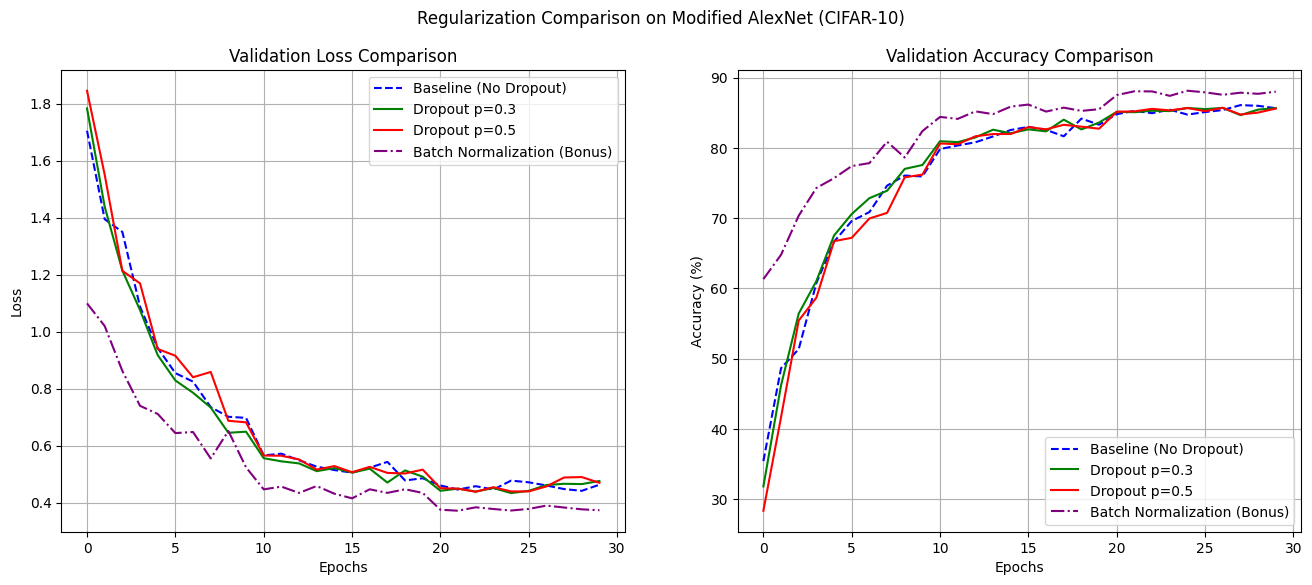

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Validation Loss
ax1.plot(val_loss_history, label='Baseline (No Dropout)', color='blue', linestyle='--')
ax1.plot(val_loss_30, label='Dropout p=0.3', color='green')
ax1.plot(val_loss_50, label='Dropout p=0.5', color='red')
ax1.plot(val_loss_bn, label='Batch Normalization (Bonus)', color='purple', linestyle='-.')
ax1.set_title('Validation Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Validation Accuracy
ax2.plot(val_acc_history, label='Baseline (No Dropout)', color='blue', linestyle='--')
ax2.plot(val_acc_30, label='Dropout p=0.3', color='green')
ax2.plot(val_acc_50, label='Dropout p=0.5', color='red')
ax2.plot(val_acc_bn, label='Batch Normalization (Bonus)', color='purple', linestyle='-.')
ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Regularization Comparison on Modified AlexNet (CIFAR-10)')
plt.show()